In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)

In [2]:
import pandas as pd
import numpy as np

df_country = pd.read_csv("co2_emissions_kt_by_country.csv")

df_country.head()

,country_code,country_name,year,value
0,ABW,Aruba,1960,11092.675
1,ABW,Aruba,1961,11576.719
2,ABW,Aruba,1962,12713.489
3,ABW,Aruba,1963,12178.107
4,ABW,Aruba,1964,11840.743


In [3]:
print(df_country.shape)

print(df_country.columns.tolist())

(13953, 4)
['country_code', 'country_name', 'year', 'value']


In [6]:
df_country.isnull().sum()

country_code    0
country_name    0
year            0
value           0
dtype: int64

In [7]:
df_country = df_country.dropna(
    subset=["value"]
)

In [8]:
latest_year = df_country["year"].max()

latest_year

2019

In [9]:
top10 = (
    df_country[
        df_country["year"] == latest_year
    ]
    .sort_values(
        by="value",
        ascending=False
    )
    .head(10)
)

top10

,country_code,country_name,year,value
13651,WLD,World,2019,3.434401e+07
5569,IBT,IDA & IBRD total,2019,2.244242e+07
7578,LMY,Low & middle income,2019,2.190943e+07
8254,MIC,Middle income,2019,2.171260e+07
5509,IBD,IBRD only,2019,2.152242e+07
13148,UMC,Upper middle income,2019,1.591866e+07
7668,LTE,Late-demographic dividend,2019,1.549953e+07
3421,EAS,East Asia & Pacific,2019,1.527588e+07
3301,EAP,East Asia & Pacific (excluding high income),2019,1.249182e+07
12158,TEA,East Asia & Pacific (IDA & IBRD countries),2019,1.243564e+07


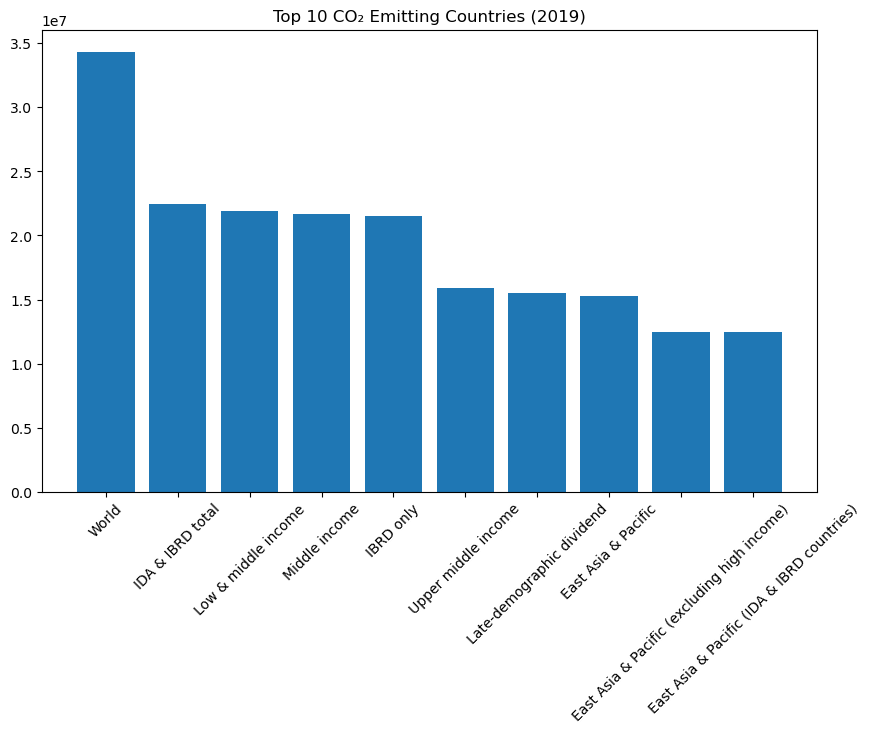

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    top10["country_name"],
    top10["value"]
)

plt.xticks(rotation=45)

plt.title(
    f"Top 10 CO₂ Emitting Countries ({latest_year})"
)

plt.show()

In [11]:
india = df_country[
    df_country["country_name"] == "India"
]

india.head()

,country_code,country_name,year,value
5810,IND,India,1960,120581.961
5811,IND,India,1961,130402.187
5812,IND,India,1962,143467.708
5813,IND,India,1963,154083.673
5814,IND,India,1964,150647.694


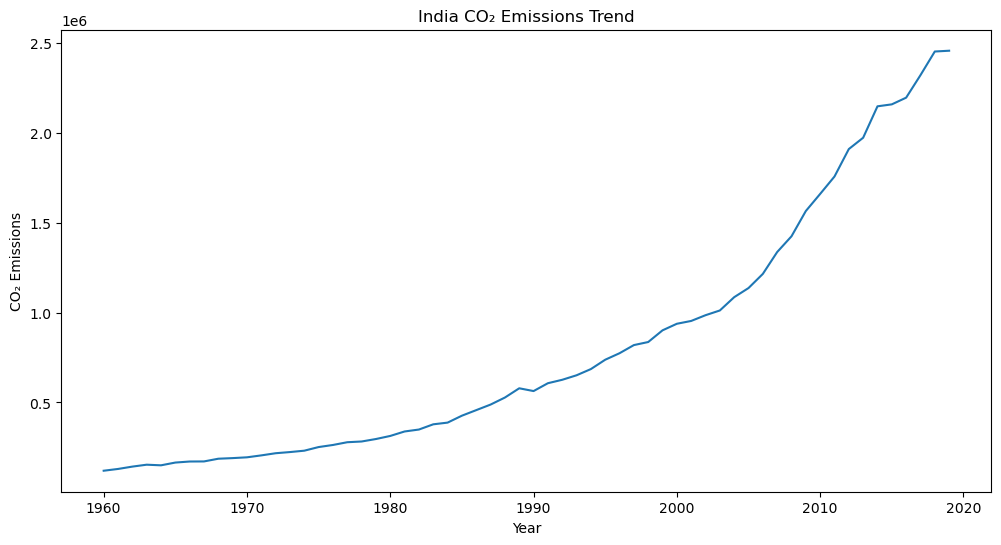

In [12]:
plt.figure(figsize=(12,6))

plt.plot(
    india["year"],
    india["value"]
)

plt.title("India CO₂ Emissions Trend")

plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.show()

In [14]:
##Forecast Model
X = india[["year"]]
y = india["value"]
from sklearn.linear_model import LinearRegression

forecast_model = LinearRegression()

forecast_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
##predict future
future_years = pd.DataFrame({
    "year":[2026,2027,2028,2029,2030]
})

future_predictions = forecast_model.predict(
    future_years
)

future_predictions

array([2139071.66041888, 2175681.49912183, 2212291.33782478,
       2248901.17652772, 2285511.01523067])

In [17]:
forecast_df = pd.DataFrame({
    "Year":future_years["year"],
    "Forecast_CO2":future_predictions
})

forecast_df

,Year,Forecast_CO2
0,2026,2.139072e+06
1,2027,2.175681e+06
2,2028,2.212291e+06
3,2029,2.248901e+06
4,2030,2.285511e+06


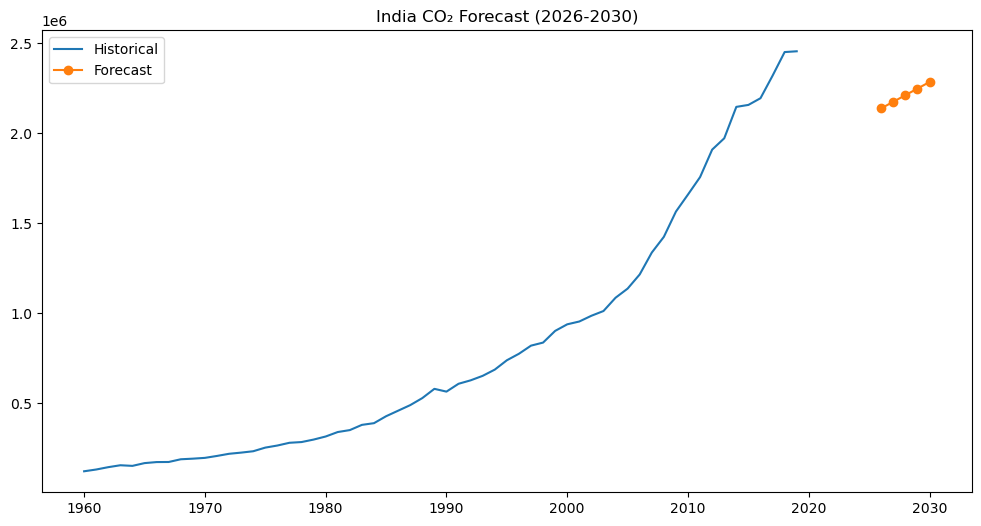

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    india["year"],
    india["value"],
    label="Historical"
)

plt.plot(
    future_years["year"],
    future_predictions,
    marker="o",
    label="Forecast"
)

plt.legend()

plt.title(
    "India CO₂ Forecast (2026-2030)"
)

plt.show()

In [23]:
import joblib

joblib.dump(
    forecast_model,
    "models/country_forecast.joblib"
)

print("Forecast Model Saved")

Forecast Model Saved
